In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (4)\LoanApprovalPrediction.csv")
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Accuracy : 0.7804878048780488

Confusion Matrix

[[18 25]
 [ 2 78]]

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123


Important Features

              Feature  Importance
10     Credit_History    0.245658
6     ApplicantIncome    0.154094
0             Loan_ID    0.152056
8          LoanAmount    0.151248
7   CoapplicantIncome    0.086406
9    Loan_Amount_Term    0.047681
11      Property_Area    0.047121
3          Dependents    0.039856
2             Married    0.022624
4           Education    0.020818
1              Gender    0.017540
5       Self_Employed    0.014899


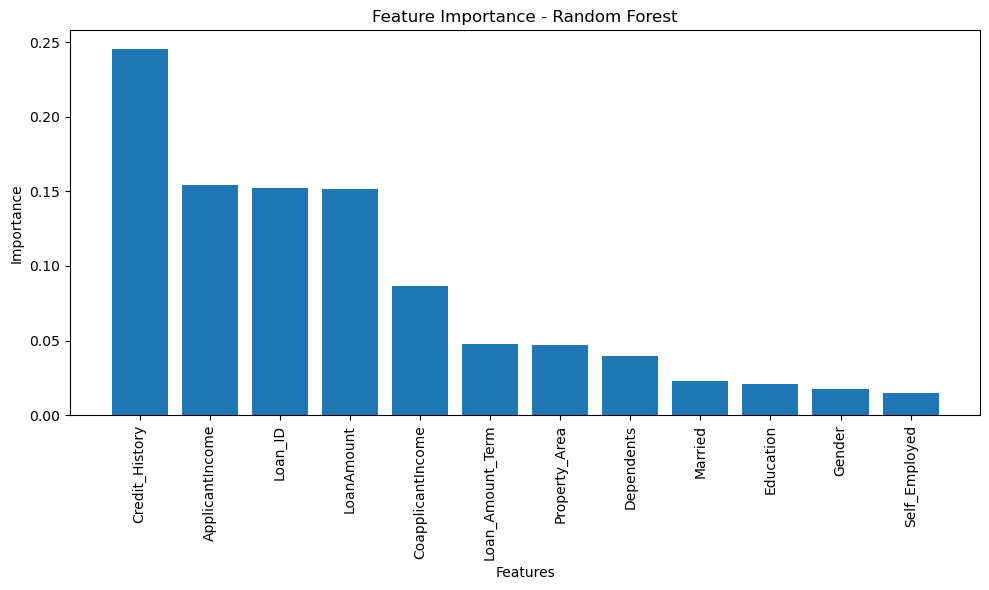

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (4)\LoanApprovalPrediction.csv")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy :", accuracy)
print("\nConfusion Matrix\n")
print(cm)
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
importance = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)
print("\nImportant Features\n")
print(feature_df)
plt.figure(figsize=(10,6))
plt.bar(feature_df['Feature'], feature_df['Importance'])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()